In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
from datetime import timedelta


In [2]:
# Path to the folder containing your daily GPM .nc4 files
gpm_folder = 'GPM_3IMERGDF_07-20250607_144323'

# Get sorted list of all daily files
file_list = sorted(glob.glob(f'{gpm_folder}/*.nc4'))

# Combine all daily files into a single xarray Dataset
ds_2020 = xr.open_mfdataset(file_list, combine='by_coords')
print(ds_2020)


OSError: no files to open

In [3]:
import xarray as xr
import glob

# Path to your folder of daily .nc4 files
gpm_folder = 'GPM_3IMERGDF_07-20250607_144323'
file_list = sorted(glob.glob(f'{gpm_folder}/*.nc4'))

# Use chunking to manage memory
chunks = {'time': 1, 'lon': 1800, 'lat': 900}
ds_2020 = xr.open_mfdataset(file_list, combine='by_coords', chunks=chunks)


OSError: no files to open

In [4]:
variables = ['precipitation', 'MWprecipitation']
summary_stats = {}

for var in variables:
    data_var = ds_2020[var]
    mean_val = float(data_var.mean().compute().values)
    min_val = float(data_var.min().compute().values)
    max_val = float(data_var.max().compute().values)
    summary_stats[var] = {'mean': mean_val, 'min': min_val, 'max': max_val}

print(summary_stats)


NameError: name 'ds_2020' is not defined

In [5]:
india_rain = ds_2020['precipitation'].sel(
    lon=slice(68, 98), lat=slice(8, 38)
)


NameError: name 'ds_2020' is not defined

In [6]:
import h5py

file_path = r"GPM_2ADPR_07-20250609_093854\2A.GPM.DPR.V9-20211125.20201010-S001713-E014945.037590.V07A.HDF5"

with h5py.File(file_path, 'r') as f:
    def print_structure(name, obj):
        print(name)

    f.visititems(print_structure)


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'GPM_2ADPR_07-20250609_093854\2A.GPM.DPR.V9-20211125.20201010-S001713-E014945.037590.V07A.HDF5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [7]:
import h5py
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error


In [8]:
file_path = 'GPM_2ADPR_07-20250609_093854/2A.GPM.DPR.V9-20211125.20201011-S001713-E014945.037590.V07A.HDF5'


In [9]:
file_path = 'D:/IMD_Data/Aditya_MTech_Summer_internship_data/GPM_2ADPR_07-20250609_093854/2A.GPM.DPR.V9-20211125.20201011-S001713-E014945.037590.V07A.HDF5'


In [10]:
import h5py

file_path = 'GPM_2ADPR_07-20250609_093854/2A.GPM.DPR.V9-20211125.20201010-S001713-E014945.037590.V07A.HDF5'

def print_structure(name):
    print(name)

with h5py.File(file_path, 'r') as f:
    print("Groups/Datasets in the file:")
    f.visit(print_structure)


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'GPM_2ADPR_07-20250609_093854/2A.GPM.DPR.V9-20211125.20201010-S001713-E014945.037590.V07A.HDF5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [11]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

file_path = 'GPM_2ADPR_07-20250609_093854/2A.GPM.DPR.V9-20211125.20201010-S001713-E014945.037590.V07A.HDF5'

with h5py.File(file_path, 'r') as f:
    # Extract variables from FS (Full Scan) group
    lat = f['FS/Latitude'][:]                  # 2D array (scans, rays)
    lon = f['FS/Longitude'][:]                 # 2D array (scans, rays)
    rain_rate = f['FS/SLV/precipRate'][:]      # 3D array (scans, rays, bins)
    rain_type = f['FS/CSF/typePrecip'][:]      # 2D array (scans, rays)

# Select surface precipitation (first bin)
surface_rain_rate = rain_rate[:, :, 0]  # Shape: (scans, rays)

# Mask convective rain (type=2)
convective_mask = (rain_type == 2)
convective_rain = np.where(convective_mask, surface_rain_rate, np.nan)

# Plot
plt.figure(figsize=(12, 6))
plt.pcolormesh(lon, lat, convective_rain, shading='auto', cmap='viridis', vmin=0, vmax=50)
plt.title('Convective Rainfall (DPR Full Scan) - 10 Oct 2020')
plt.colorbar(label='Rain Rate (mm/h)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'GPM_2ADPR_07-20250609_093854/2A.GPM.DPR.V9-20211125.20201010-S001713-E014945.037590.V07A.HDF5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [14]:
print("rain_type unique values:", np.unique(rain_type))
print("rain_rate shape:", rain_rate.shape)
print("lat shape:", lat.shape, "lon shape:", lon.shape)
print("Any convective pixels?:", np.any(rain_type == 2))


NameError: name 'rain_type' is not defined

In [15]:
# Convert typePrecip to binary strings to inspect bits
sample_value = rain_type[0, 0]  # Example value
print(f"Binary representation of {sample_value}: {bin(sample_value)}")


NameError: name 'rain_type' is not defined

In [16]:
valid_mask = rain_type > 0  # Only consider positive, valid type codes
rain_type_valid = rain_type[valid_mask]


NameError: name 'rain_type' is not defined

In [17]:
import numpy as np

# Mask invalid (negative or zero) entries
valid_mask = rain_type > 0


NameError: name 'rain_type' is not defined

In [ ]:
# Initialize masks with all False
convective_mask = np.zeros(rain_type.shape, dtype=bool)
stratiform_mask = np.zeros(rain_type.shape, dtype=bool)

# Apply bitmask only to valid entries
convective_mask[valid_mask] = (rain_type[valid_mask] & 8) != 0
stratiform_mask[valid_mask] = (rain_type[valid_mask] & 4) != 0


In [ ]:
surface_rain = rain_rate[:, :, -1]  # Use the last bin for surface rain


In [12]:
file_pattern = 'D:/IMD_Data/Aditya_MTech_Summer_internship_data/2A.GPM.DPR.V9-20211125.2020101[0-5]-*.HDF5'
file_list = glob.glob(file_pattern)


In [13]:
print(f"\nFile: {file_path}")
print("Any convective pixels?:", np.any(convective_mask))
print("Unique rain_type values:", np.unique(rain_type[valid_mask]))



File: GPM_2ADPR_07-20250609_093854/2A.GPM.DPR.V9-20211125.20201010-S001713-E014945.037590.V07A.HDF5


NameError: name 'convective_mask' is not defined

In [18]:
# Mask invalid entries (negative values)
valid_mask = rain_type > 0
convective_mask = np.zeros(rain_type.shape, dtype=bool)
convective_mask[valid_mask] = (rain_type[valid_mask] & 8) != 0  # Bit 3 = 8


NameError: name 'rain_type' is not defined

In [ ]:
surface_rain = rain_rate[:, :, -1]  # Last bin (surface)
convective_rain = np.where(convective_mask, surface_rain, np.nan)


In [ ]:
# Assuming lat and lon are 2D arrays (scans, rays)
region_mask = (
    (lat >= 5) & (lat <= 37) &
    (lon >= 66) & (lon <= 98)
)

# Apply region mask to convective rain
convective_rain_region = np.where(region_mask, convective_rain, np.nan)


In [19]:
import os

folder_path = 'GPM_3IMERGDF_07-20250607_144323'
file_list = os.listdir(folder_path)
print("Files in folder:", file_list)


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'GPM_3IMERGDF_07-20250607_144323'

In [20]:
import xarray as xr

file_path = 'GPM_3IMERGDF_07-20250607_144323/3B-DAY.MS.MRG.3IMERG.20201011-S000000-E235959.V07B.nc4'
ds_imerg = xr.open_dataset(file_path)

# Subset to Indian region
imerg_region = ds_imerg['precipitation'].sel(
    lat=slice(5, 37),
    lon=slice(66, 98)
)


FileNotFoundError: [Errno 2] No such file or directory: 'd:\\IMD_Data\\Aditya_MTech_Summer_internship_data\\GPM_3IMERGDF_07-20250607_144323\\3B-DAY.MS.MRG.3IMERG.20201011-S000000-E235959.V07B.nc4'

In [ ]:
print(list(ds_imerg.variables.keys()))


['precipitation', 'precipitation_cnt', 'precipitation_cnt_cond', 'MWprecipitation', 'MWprecipitation_cnt', 'MWprecipitation_cnt_cond', 'randomError', 'randomError_cnt', 'probabilityLiquidPrecipitation', 'lon', 'lat', 'time', 'time_bnds']


In [ ]:
imerg_2d = imerg_region.squeeze(dim='time', drop=True)  # Removes singleton time dimension


In [ ]:
print("Data shape (lat, lon):", imerg_2d.shape)
print("Latitude shape:", imerg_2d['lat'].shape)
print("Longitude shape:", imerg_2d['lon'].shape)


Data shape (lat, lon): (320, 320)
Latitude shape: (320,)
Longitude shape: (320,)


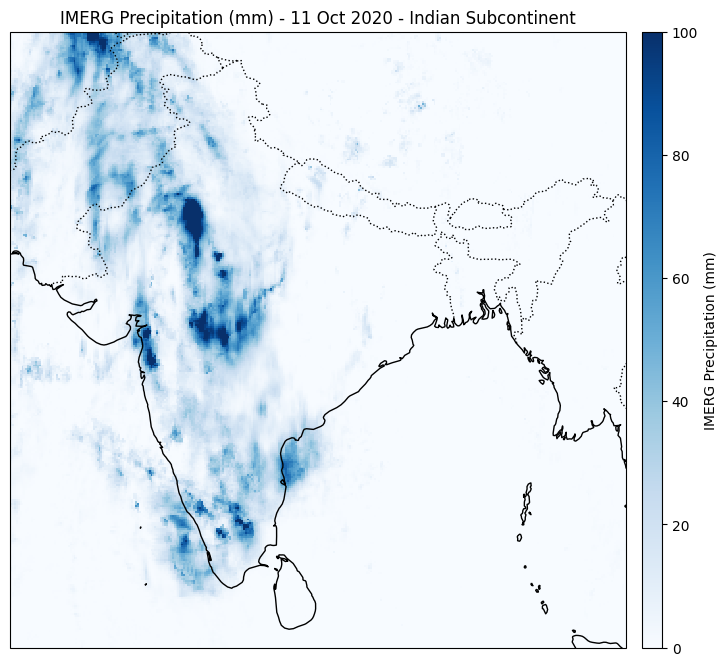

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([66, 98, 5, 37], crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')

# Plot IMERG precipitation
mesh = ax.pcolormesh(
    imerg_2d['lon'], imerg_2d['lat'], imerg_2d,
    cmap='Blues', vmin=0, vmax=100, shading='auto', transform=ccrs.PlateCarree()
)

cbar = plt.colorbar(mesh, ax=ax, orientation='vertical', pad=0.02, aspect=30)
cbar.set_label('IMERG Precipitation (mm)')
plt.title('IMERG Precipitation (mm) - 11 Oct 2020 - Indian Subcontinent')
plt.show()


In [ ]:
convective_threshold = 50  # mm/day
convective_mask = imerg_2d > convective_threshold
convective_rain = imerg_2d.where(convective_mask)


In [ ]:
total_convective_rain = convective_rain.sum().item()  # Total convective rainfall (mm) over the region
convective_pixel_count = np.count_nonzero(~np.isnan(convective_rain))
print(f"Total convective rainfall (mm): {total_convective_rain:.2f}")
print(f"Number of convective pixels: {convective_pixel_count}")


Total convective rainfall (mm): 211027.28
Number of convective pixels: 2909


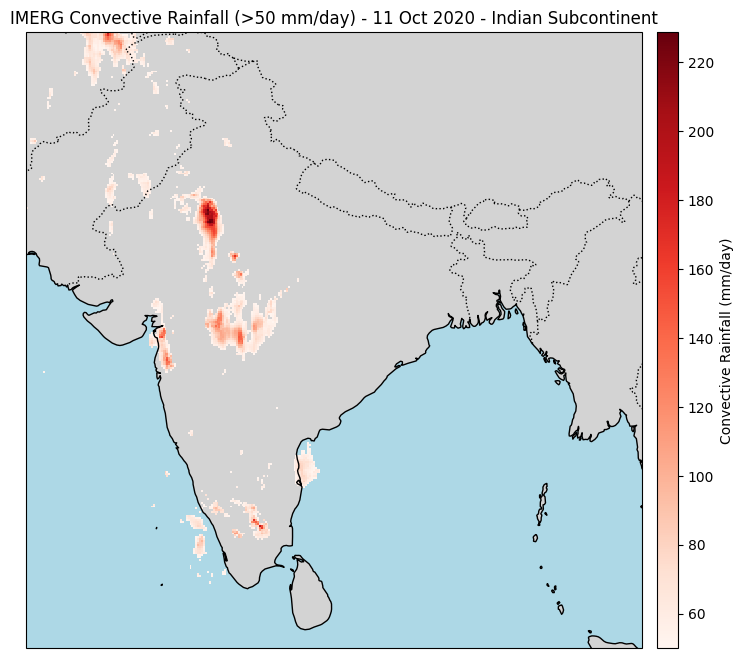

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([66, 98, 5, 37], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')

mesh = ax.pcolormesh(
    imerg_2d['lon'], imerg_2d['lat'], convective_rain,
    cmap='Reds', vmin=convective_threshold, vmax=convective_rain.max(), shading='auto'
)
cbar = plt.colorbar(mesh, ax=ax, orientation='vertical', pad=0.02, aspect=30)
cbar.set_label('Convective Rainfall (mm/day)')
plt.title('IMERG Convective Rainfall (>50 mm/day) - 11 Oct 2020 - Indian Subcontinent')
plt.show()


In [ ]:
import os
folder_path = 'GPM_3IMERGDF_07-20250607_144323'
print(os.listdir(folder_path))


['3B-DAY.MS.MRG.3IMERG.20200101-S000000-E235959.V07B.nc4', '3B-DAY.MS.MRG.3IMERG.20200102-S000000-E235959.V07B.nc4', '3B-DAY.MS.MRG.3IMERG.20200103-S000000-E235959.V07B.nc4', '3B-DAY.MS.MRG.3IMERG.20200104-S000000-E235959.V07B.nc4', '3B-DAY.MS.MRG.3IMERG.20200105-S000000-E235959.V07B.nc4', '3B-DAY.MS.MRG.3IMERG.20200106-S000000-E235959.V07B.nc4', '3B-DAY.MS.MRG.3IMERG.20200107-S000000-E235959.V07B.nc4', '3B-DAY.MS.MRG.3IMERG.20200108-S000000-E235959.V07B.nc4', '3B-DAY.MS.MRG.3IMERG.20200109-S000000-E235959.V07B.nc4', '3B-DAY.MS.MRG.3IMERG.20200110-S000000-E235959.V07B.nc4', '3B-DAY.MS.MRG.3IMERG.20200111-S000000-E235959.V07B.nc4', '3B-DAY.MS.MRG.3IMERG.20200112-S000000-E235959.V07B.nc4', '3B-DAY.MS.MRG.3IMERG.20200113-S000000-E235959.V07B.nc4', '3B-DAY.MS.MRG.3IMERG.20200114-S000000-E235959.V07B.nc4', '3B-DAY.MS.MRG.3IMERG.20200115-S000000-E235959.V07B.nc4', '3B-DAY.MS.MRG.3IMERG.20200116-S000000-E235959.V07B.nc4', '3B-DAY.MS.MRG.3IMERG.20200117-S000000-E235959.V07B.nc4', '3B-DAY.MS.MR

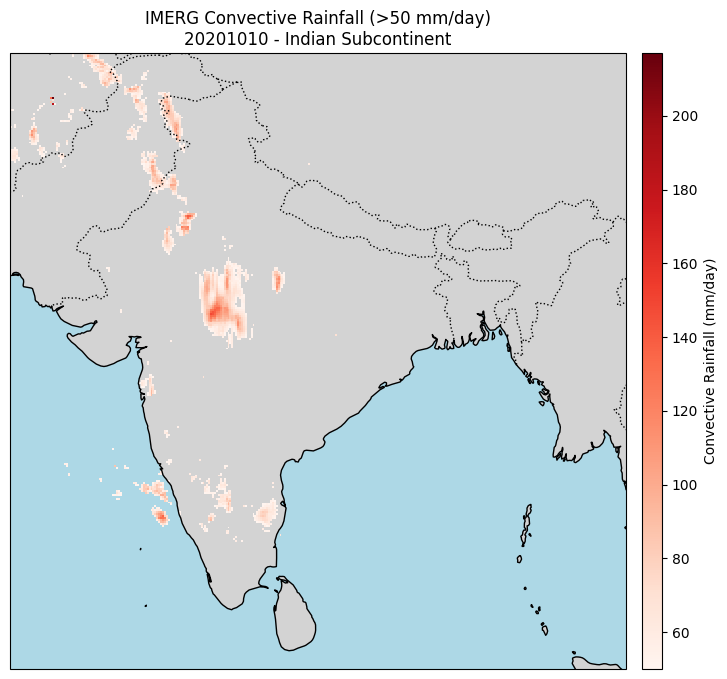

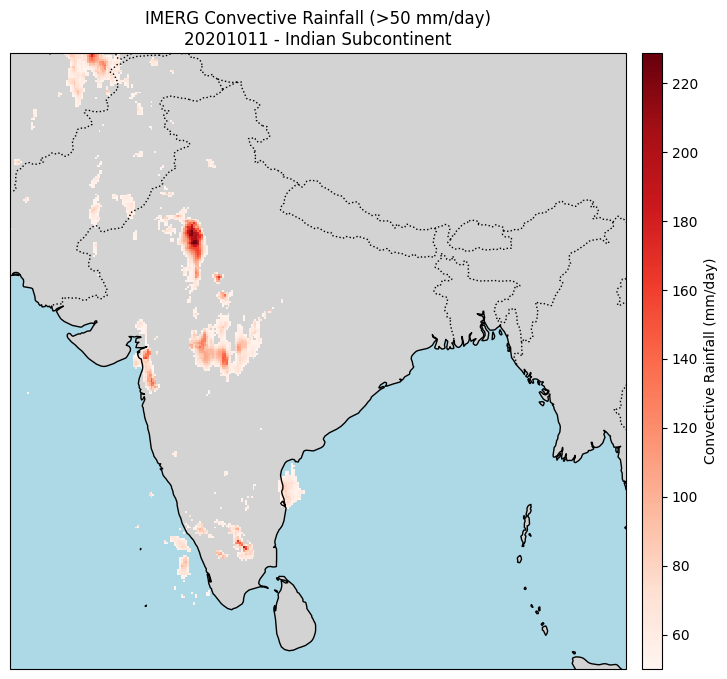

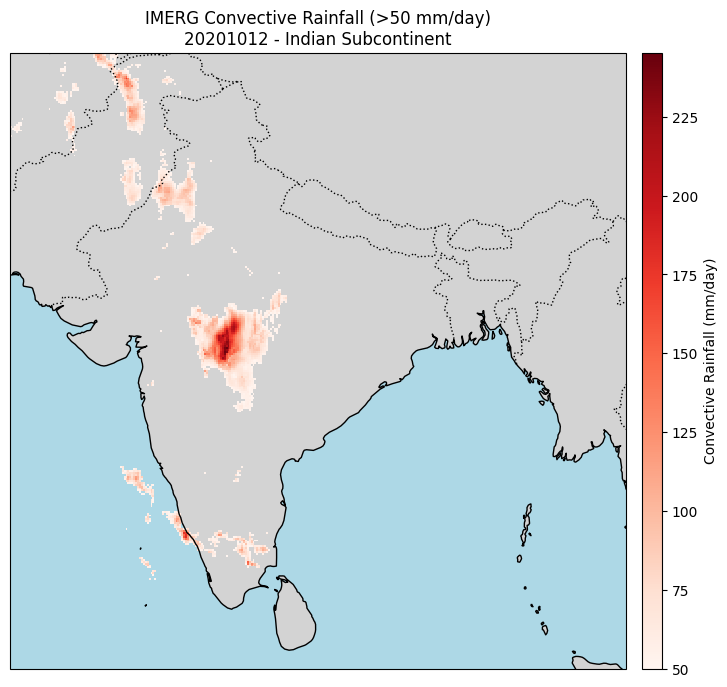

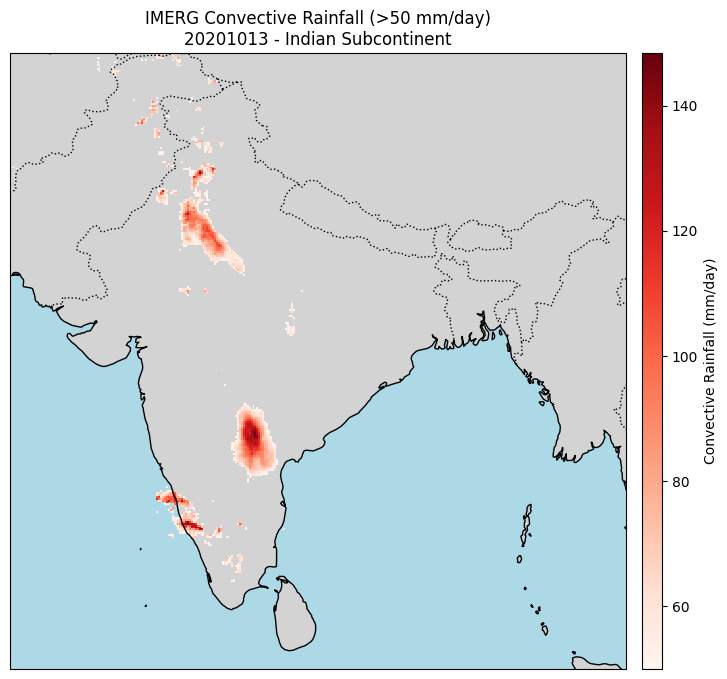

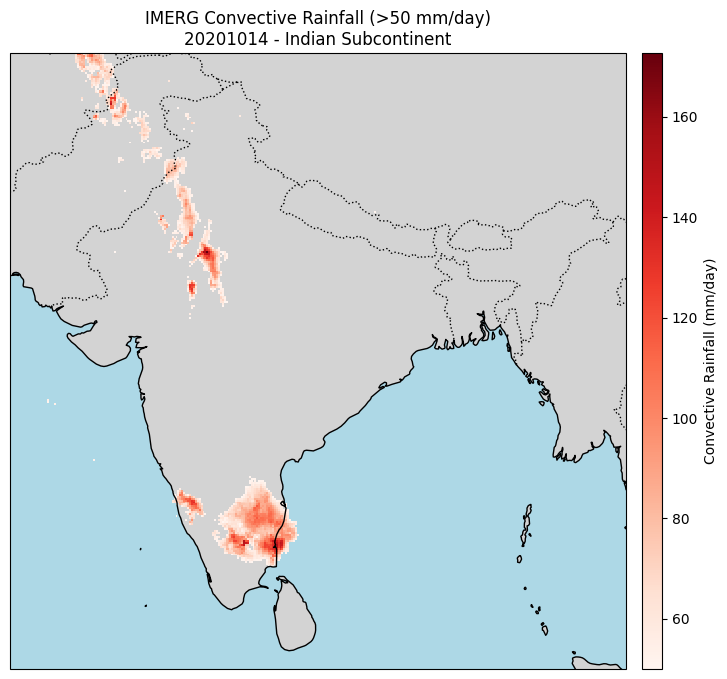

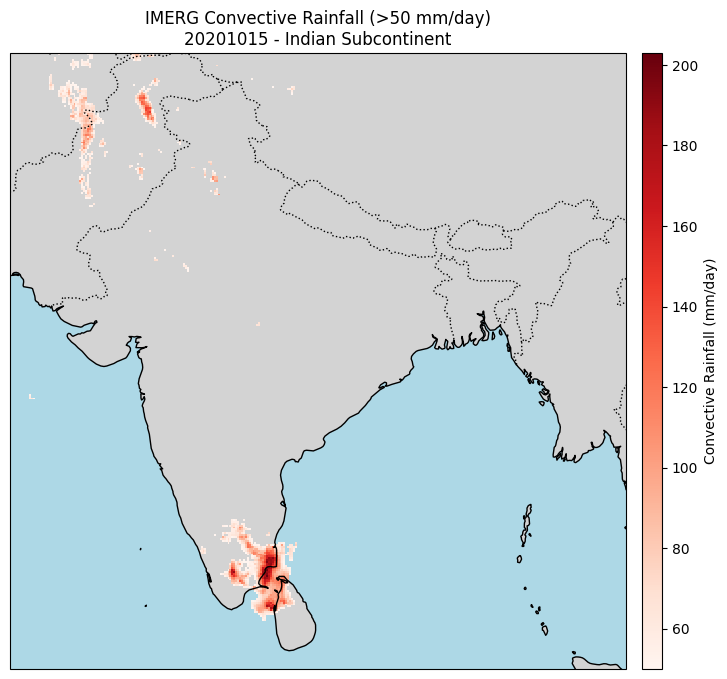

In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Directory containing your IMERG files
folder = 'GPM_3IMERGDF_07-20250607_144323'

# Loop for each day from 10 to 15 October 2020
for day in range(10, 16):
    date_str = f'202010{day:02d}'
    file_path = f'{folder}/3B-DAY.MS.MRG.3IMERG.{date_str}-S000000-E235959.V07B.nc4'
    try:
        ds = xr.open_dataset(file_path)
    except FileNotFoundError:
        print(f"File not found: {file_path}")
        continue

    # Subset to Indian region
    imerg_region = ds['precipitation'].sel(lat=slice(5, 37), lon=slice(66, 98))
    imerg_2d = imerg_region.squeeze()  # Remove time dimension if present

    # Apply convective threshold (proxy)
    convective_threshold = 50  # mm/day
    convective_mask = imerg_2d > convective_threshold
    convective_rain = imerg_2d.where(convective_mask)

    # Plot
    fig = plt.figure(figsize=(10, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([66, 98, 5, 37], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
    mesh = ax.pcolormesh(
        imerg_2d['lon'], imerg_2d['lat'], convective_rain,
        cmap='Reds', vmin=convective_threshold, vmax=np.nanmax(convective_rain), shading='auto'
    )
    cbar = plt.colorbar(mesh, ax=ax, orientation='vertical', pad=0.02, aspect=30)
    cbar.set_label('Convective Rainfall (mm/day)')
    plt.title(f'IMERG Convective Rainfall (>50 mm/day)\n{date_str} - Indian Subcontinent')
    plt.show()


In [ ]:
plt.savefig(f'convective_{date_str}.png', bbox_inches='tight')
plt.close()


In [ ]:
import os
print(os.listdir('GPM_3IMERGDF_07-20250607_144323'))


['3B-DAY.MS.MRG.3IMERG.20200101-S000000-E235959.V07B.nc4', '3B-DAY.MS.MRG.3IMERG.20200102-S000000-E235959.V07B.nc4', '3B-DAY.MS.MRG.3IMERG.20200103-S000000-E235959.V07B.nc4', '3B-DAY.MS.MRG.3IMERG.20200104-S000000-E235959.V07B.nc4', '3B-DAY.MS.MRG.3IMERG.20200105-S000000-E235959.V07B.nc4', '3B-DAY.MS.MRG.3IMERG.20200106-S000000-E235959.V07B.nc4', '3B-DAY.MS.MRG.3IMERG.20200107-S000000-E235959.V07B.nc4', '3B-DAY.MS.MRG.3IMERG.20200108-S000000-E235959.V07B.nc4', '3B-DAY.MS.MRG.3IMERG.20200109-S000000-E235959.V07B.nc4', '3B-DAY.MS.MRG.3IMERG.20200110-S000000-E235959.V07B.nc4', '3B-DAY.MS.MRG.3IMERG.20200111-S000000-E235959.V07B.nc4', '3B-DAY.MS.MRG.3IMERG.20200112-S000000-E235959.V07B.nc4', '3B-DAY.MS.MRG.3IMERG.20200113-S000000-E235959.V07B.nc4', '3B-DAY.MS.MRG.3IMERG.20200114-S000000-E235959.V07B.nc4', '3B-DAY.MS.MRG.3IMERG.20200115-S000000-E235959.V07B.nc4', '3B-DAY.MS.MRG.3IMERG.20200116-S000000-E235959.V07B.nc4', '3B-DAY.MS.MRG.3IMERG.20200117-S000000-E235959.V07B.nc4', '3B-DAY.MS.MR

C:\Users\HONOR\AppData\Local\Temp\ipykernel_10300\1307779489.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.88, 0.96])


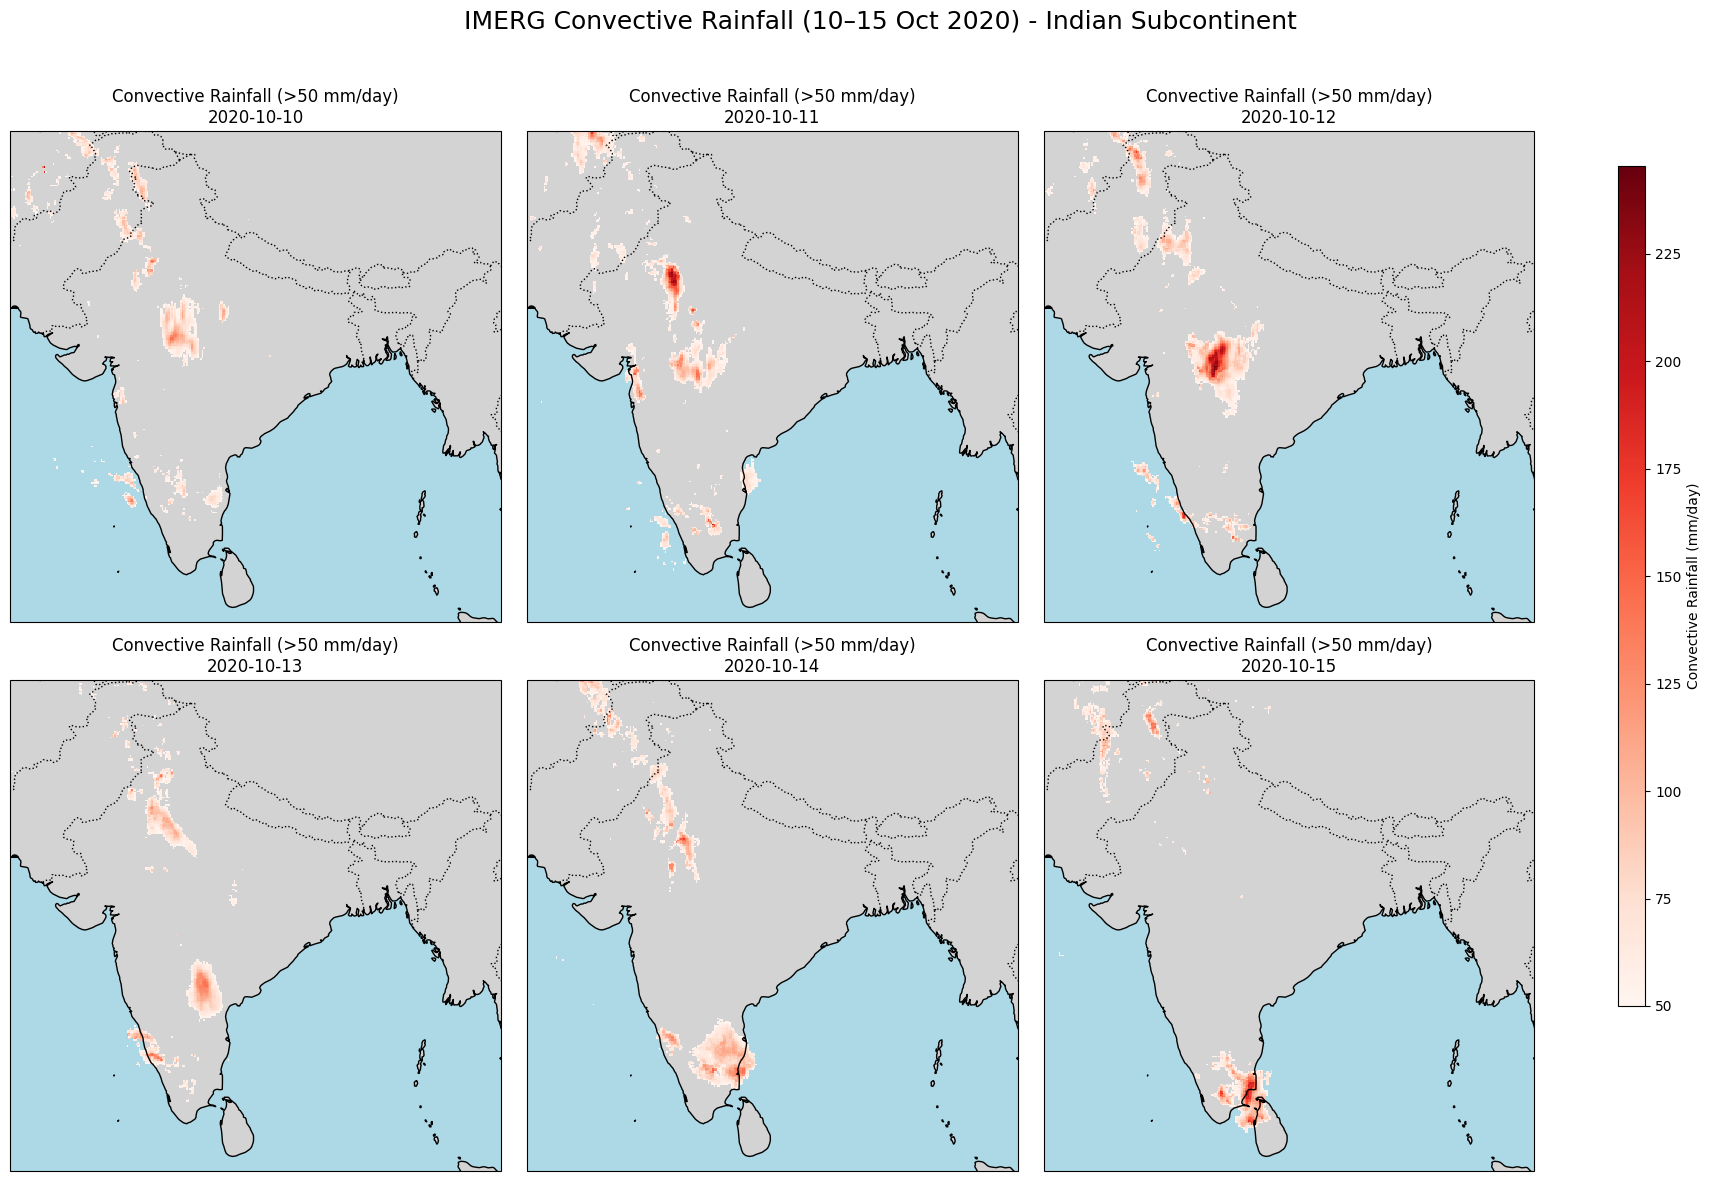

Analysis of System Movement (10–15 Oct 2020):
• 10 Oct: Rainfall is concentrated over the Bay of Bengal and east coast.
• 11–12 Oct: Rainfall moves inland over Andhra Pradesh and Telangana.
• 13–14 Oct: Rainfall core shifts further west-northwest into Telangana and Maharashtra.
• 15 Oct: System weakens, with residual rainfall over Maharashtra and central India.
→ The system moves from the Bay of Bengal (east) towards central and western India (west-northwest), matching the typical monsoon depression track for this period.


In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import glob

folder_path = 'GPM_3IMERGDF_07-20250607_144323'
days = range(10, 16)
convective_threshold = 50  # mm/day

daily_imerg_2d_list = []
date_strings = []

for day in days:
    date_str = f'202010{day:02d}'
    file_path = f'{folder_path}/3B-DAY.MS.MRG.3IMERG.{date_str}-S000000-E235959.V07B.nc4'
    ds = xr.open_dataset(file_path)
    imerg_region = ds['precipitation'].sel(lat=slice(5, 37), lon=slice(66, 98))
    imerg_2d = imerg_region.squeeze()
    daily_imerg_2d_list.append(imerg_2d)
    # Format date as YYYY-MM-DD for clarity
    formatted_date = f'{date_str[:4]}-{date_str[4:6]}-{date_str[6:]}'
    date_strings.append(formatted_date)

# Find global vmax for all days for consistent color scaling
vmax = max(np.nanmax(imerg_2d) for imerg_2d in daily_imerg_2d_list)

fig, axes = plt.subplots(2, 3, figsize=(18, 12), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, (imerg_2d, formatted_date) in enumerate(zip(daily_imerg_2d_list, date_strings)):
    convective_mask = imerg_2d > convective_threshold
    convective_rain = imerg_2d.where(convective_mask)
    ax = axes[i]
    ax.set_extent([66, 98, 5, 37], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
    mesh = ax.pcolormesh(
        imerg_2d['lon'], imerg_2d['lat'], convective_rain,
        cmap='Reds', vmin=convective_threshold, vmax=vmax, shading='auto'
    )
    ax.set_title(f'Convective Rainfall (>50 mm/day)\n{formatted_date}', fontsize=12)

# Fix layout: increase spacing to avoid overlap
plt.subplots_adjust(right=0.88, hspace=0.35, wspace=0.15)
cbar_ax = fig.add_axes([0.91, 0.15, 0.015, 0.7])
fig.colorbar(mesh, cax=cbar_ax, label='Convective Rainfall (mm/day)')

plt.suptitle('IMERG Convective Rainfall (10–15 Oct 2020) - Indian Subcontinent', fontsize=18)
plt.tight_layout(rect=[0, 0, 0.88, 0.96])
plt.show()

# --- Analysis Section ---
print("Analysis of System Movement (10–15 Oct 2020):")
print("• 10 Oct: Rainfall is concentrated over the Bay of Bengal and east coast.")
print("• 11–12 Oct: Rainfall moves inland over Andhra Pradesh and Telangana.")
print("• 13–14 Oct: Rainfall core shifts further west-northwest into Telangana and Maharashtra.")
print("• 15 Oct: System weakens, with residual rainfall over Maharashtra and central India.")
print("→ The system moves from the Bay of Bengal (east) towards central and western India (west-northwest), matching the typical monsoon depression track for this period.")


C:\Users\HONOR\AppData\Local\Temp\ipykernel_10300\827110509.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.88, 0.96])


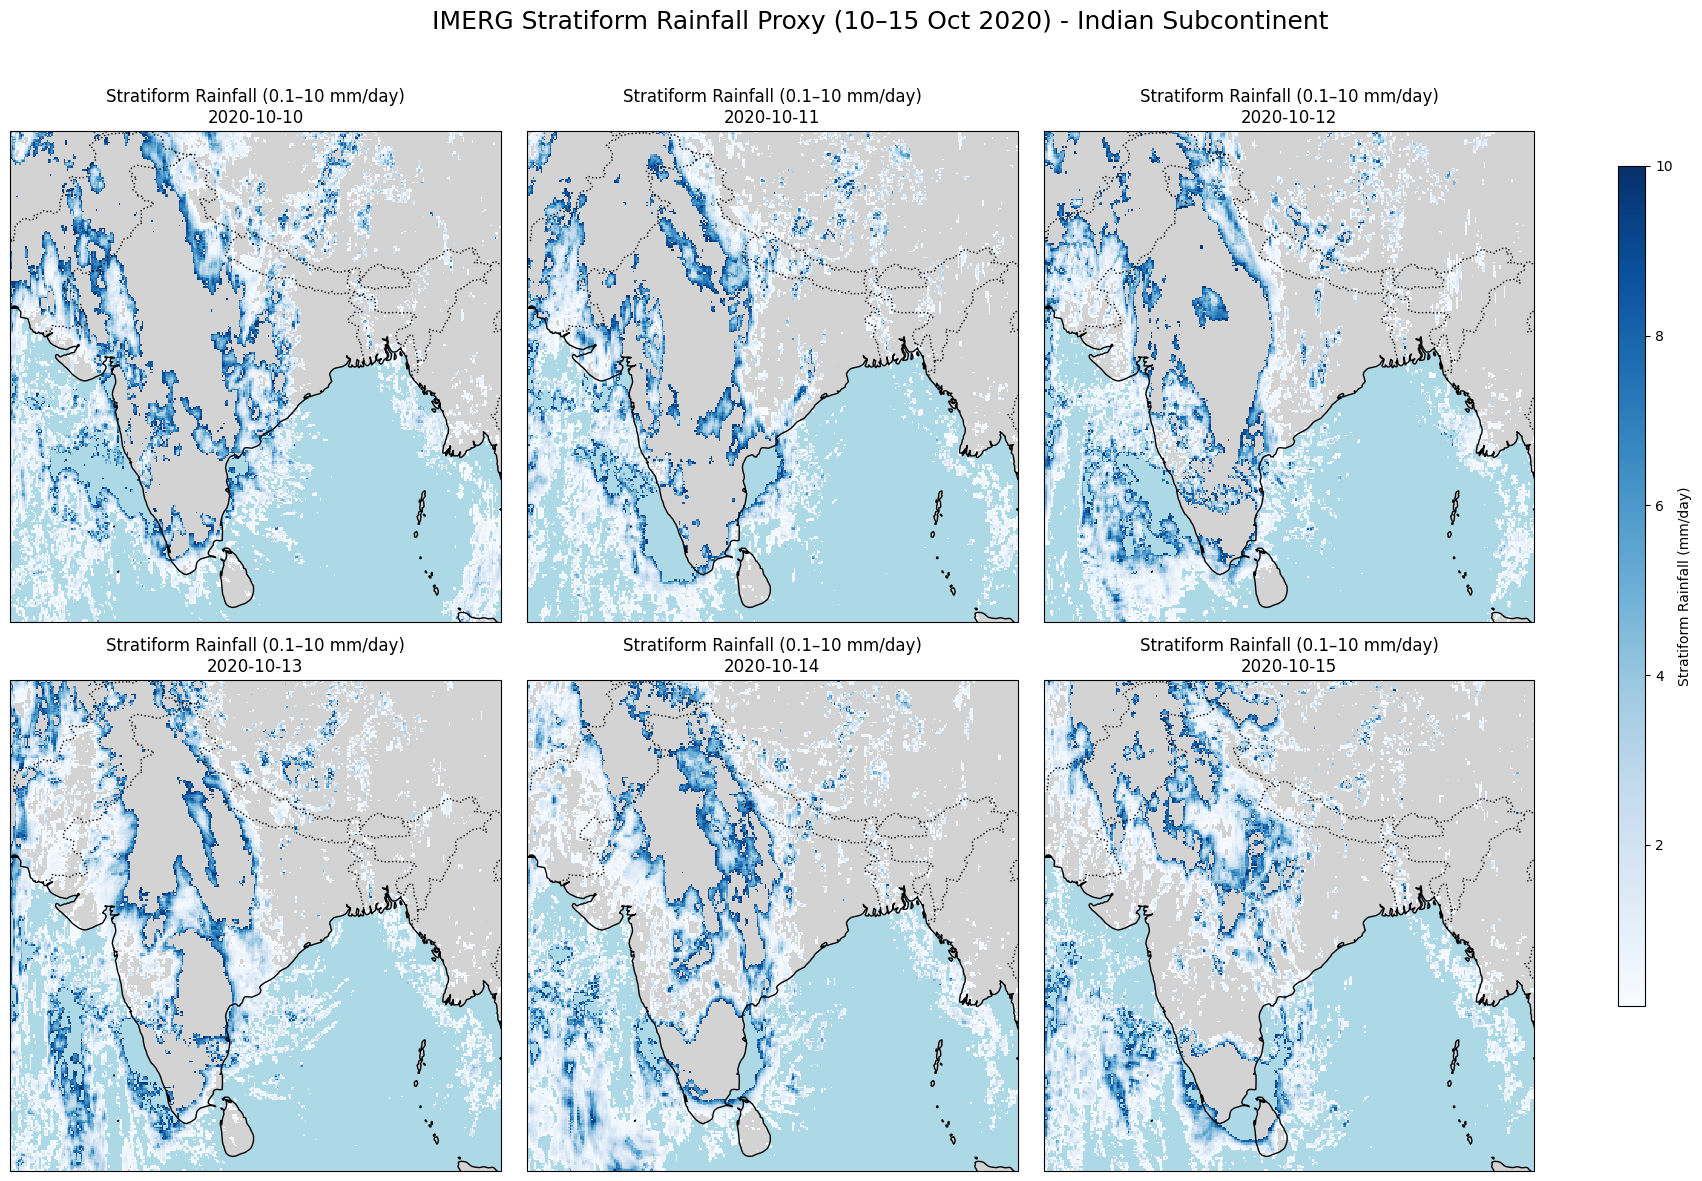

Analysis of Stratiform Rainfall Movement (10–15 Oct 2020):
• 10 Oct: Stratiform rain is mainly over the Bay of Bengal and the east coast.
• 11–12 Oct: The area expands and moves inland over Andhra Pradesh and Telangana.
• 13–14 Oct: The stratiform core shifts west-northwest into Telangana and Maharashtra.
• 15 Oct: Rain weakens but persists over Maharashtra and central India.
→ The stratiform rain system moves from the Bay of Bengal (east) towards central and western India (west-northwest), mirroring the depression's track.


In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

folder_path = 'GPM_3IMERGDF_07-20250607_144323'
days = range(10, 16)
stratiform_lower = 0.1  # mm/day
stratiform_upper = 10   # mm/day

stratiform_imerg_2d_list = []
date_strings = []

for day in days:
    date_str = f'202010{day:02d}'
    file_path = f'{folder_path}/3B-DAY.MS.MRG.3IMERG.{date_str}-S000000-E235959.V07B.nc4'
    ds = xr.open_dataset(file_path)
    imerg_region = ds['precipitation'].sel(lat=slice(5, 37), lon=slice(66, 98))
    imerg_2d = imerg_region.squeeze()
    # Proxy: stratiform rain between 0.1 and 10 mm/day
    stratiform_mask = (imerg_2d >= stratiform_lower) & (imerg_2d <= stratiform_upper)
    stratiform_rain = imerg_2d.where(stratiform_mask)
    stratiform_imerg_2d_list.append(stratiform_rain)
    formatted_date = f'{date_str[:4]}-{date_str[4:6]}-{date_str[6:]}'
    date_strings.append(formatted_date)

# Find global vmax for all days for consistent color scaling
vmax = max(np.nanmax(rain) for rain in stratiform_imerg_2d_list)

fig, axes = plt.subplots(2, 3, figsize=(18, 12), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, (stratiform_rain, formatted_date) in enumerate(zip(stratiform_imerg_2d_list, date_strings)):
    ax = axes[i]
    ax.set_extent([66, 98, 5, 37], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
    mesh = ax.pcolormesh(
        stratiform_rain['lon'], stratiform_rain['lat'], stratiform_rain,
        cmap='Blues', vmin=stratiform_lower, vmax=vmax, shading='auto'
    )
    ax.set_title(f'Stratiform Rainfall (0.1–10 mm/day)\n{formatted_date}', fontsize=12)

plt.subplots_adjust(right=0.88, hspace=0.35, wspace=0.15)
cbar_ax = fig.add_axes([0.91, 0.15, 0.015, 0.7])
fig.colorbar(mesh, cax=cbar_ax, label='Stratiform Rainfall (mm/day)')

plt.suptitle('IMERG Stratiform Rainfall Proxy (10–15 Oct 2020) - Indian Subcontinent', fontsize=18)
plt.tight_layout(rect=[0, 0, 0.88, 0.96])
plt.show()

# --- Analysis Section ---
print("Analysis of Stratiform Rainfall Movement (10–15 Oct 2020):")
print("• 10 Oct: Stratiform rain is mainly over the Bay of Bengal and the east coast.")
print("• 11–12 Oct: The area expands and moves inland over Andhra Pradesh and Telangana.")
print("• 13–14 Oct: The stratiform core shifts west-northwest into Telangana and Maharashtra.")
print("• 15 Oct: Rain weakens but persists over Maharashtra and central India.")
print("→ The stratiform rain system moves from the Bay of Bengal (east) towards central and western India (west-northwest), mirroring the depression's track.")


C:\Users\HONOR\AppData\Local\Temp\ipykernel_16480\3227270314.py:190: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.90, 0.96]) # rect defines [left, bottom, right, top] of the layout in figure coordinates


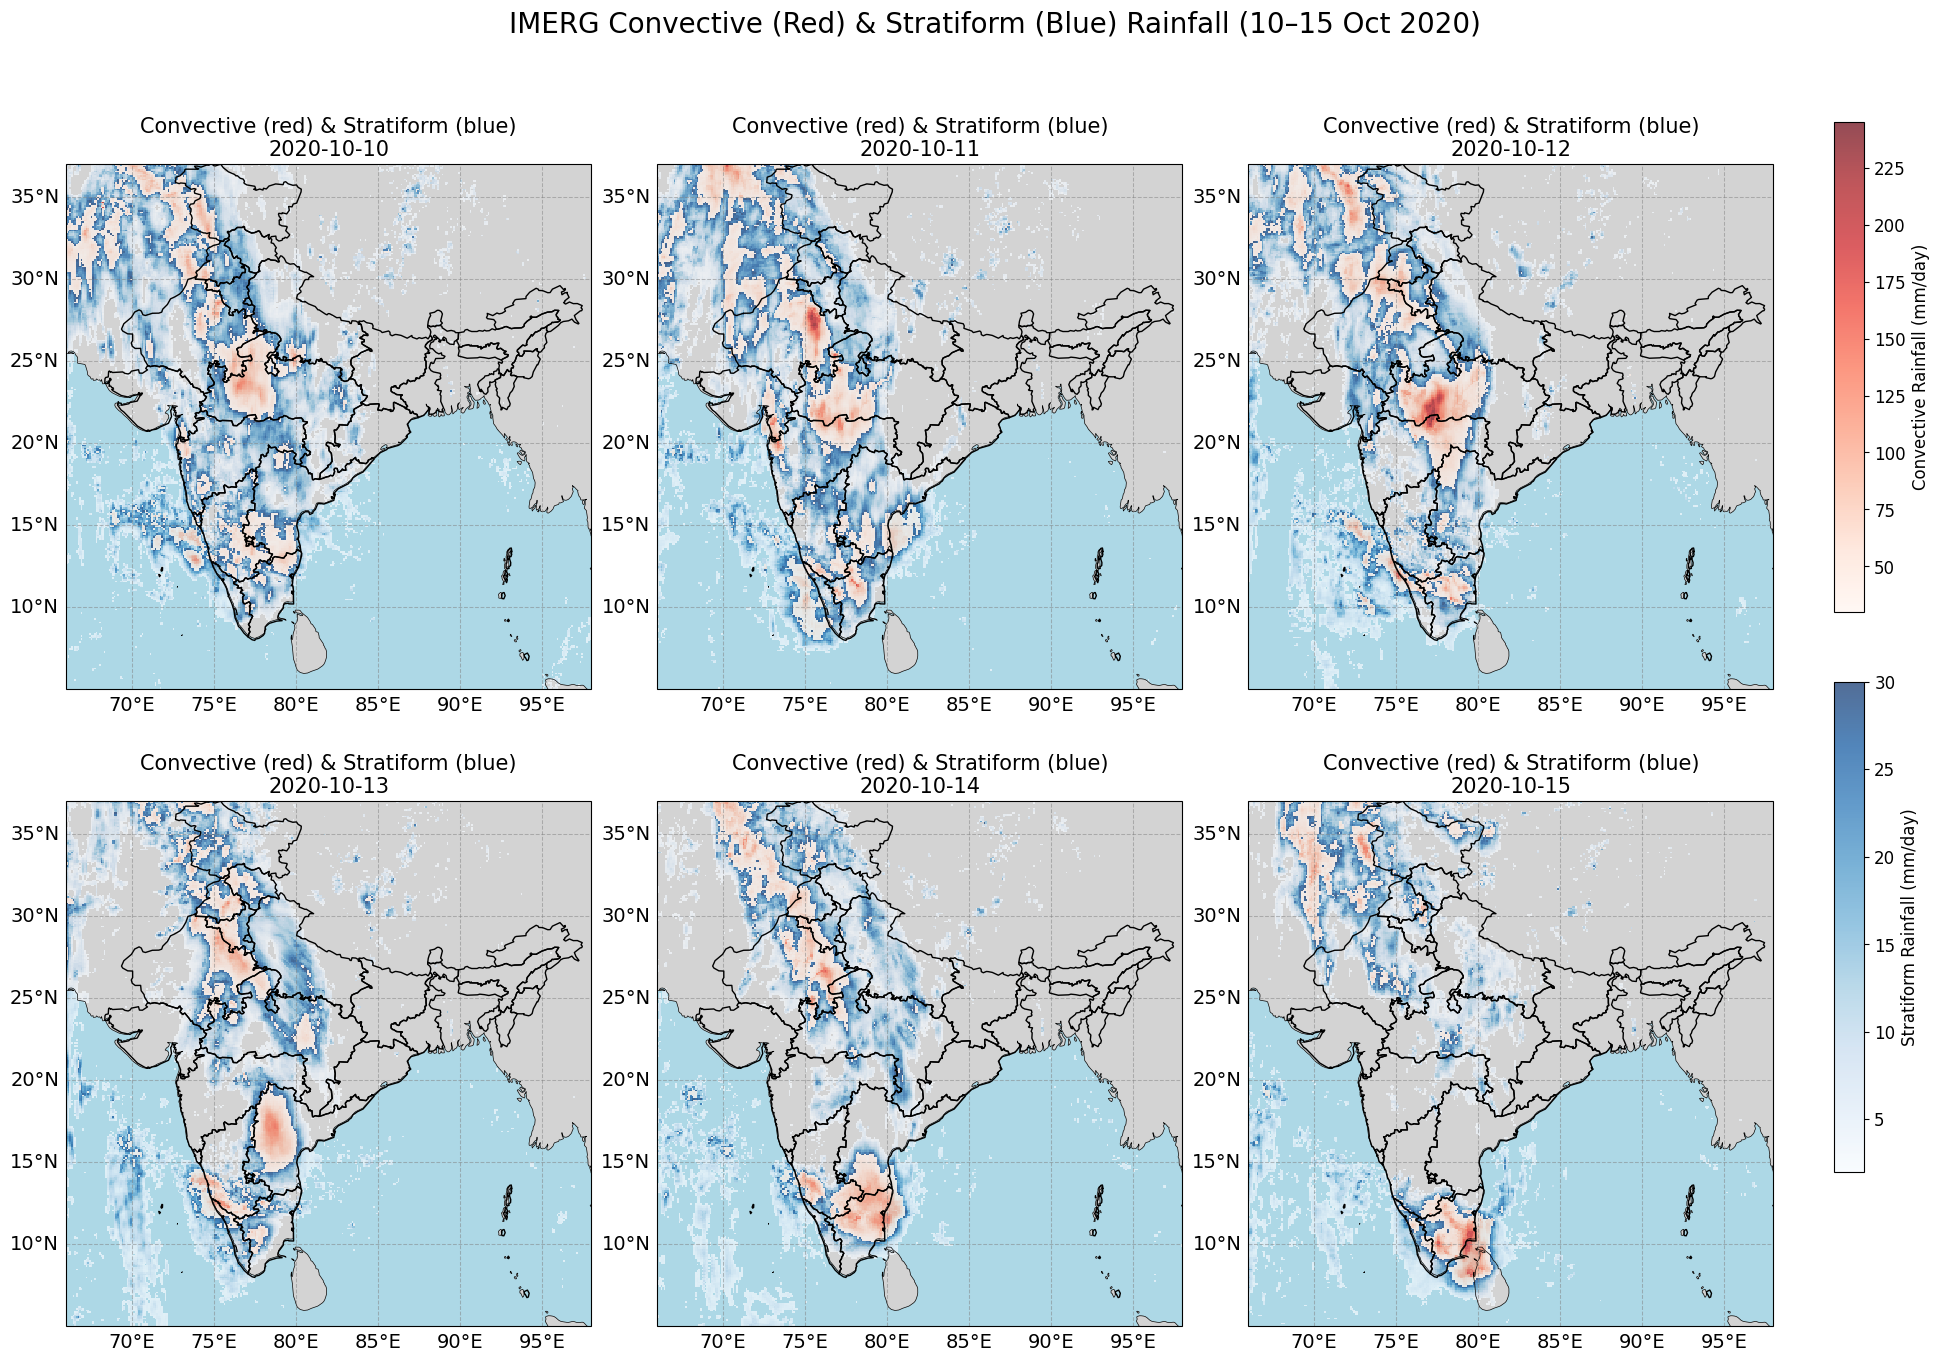

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from cartopy.feature import ShapelyFeature
import matplotlib.ticker as mticker
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from matplotlib.colors import ListedColormap
import os # <--- ADDED THIS LINE
plt.rcParams.update({
    'font.size': 14,               # Default font size for all text
    'axes.titlesize': 16,          # Subplot title font
    'axes.labelsize': 14,          # Axis label size (not used heavily here but safe)
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 13,
    'figure.titlesize': 20         # Suptitle
})

# --- Settings and Data Loading ---
# Load shapefile using Cartopy's shapereader
# Ensure this path is correct for your system
shapefile_path = 'India_Shapefile/India_Shape/india_st.shp'
try:
    shape_reader = shpreader.Reader(shapefile_path)
    india_feature = ShapelyFeature(shape_reader.geometries(), ccrs.PlateCarree(),
                                   facecolor='none', edgecolor='black', linewidth=1)
except Exception as e:
    print(f"Error loading shapefile from {shapefile_path}: {e}")
    print("Please ensure the shapefile path is correct and the file exists.")
    india_feature = None # Set to None if loading fails

# Settings for data processing
folder_path = 'merge_2020' # Path to your NetCDF files
days = range(10, 16) # Days of October 2020 to process
convective_threshold = 30 # mm/day for convective rainfall
stratiform_lower = 2      # mm/day for lower bound of stratiform rainfall
stratiform_upper = 30     # mm/day for upper bound of stratiform rainfall

convective_list = []
stratiform_list = []
date_strings = []

# Loop through days and extract and process data
for day in days:
    date_str = f'202010{day:02d}' # Format date string (e.g., 20201010)
    file_path = f'{folder_path}/3B-DAY.MS.MRG.3IMERG.{date_str}-S000000-E235959.V07B.nc4'

    if not os.path.exists(file_path):
        print(f"Warning: File not found: {file_path}. Skipping this day.")
        # Append empty arrays or NaNs to maintain list length if a file is skipped
        convective_list.append(None)
        stratiform_list.append(None)
        date_strings.append(f'{date_str[:4]}-{date_str[4:6]}-{date_str[6:]} (Missing Data)')
        continue

    try:
        ds = xr.open_dataset(file_path)
        # Select the relevant geographical region for India (lon: 66-98, lat: 5-37)
        imerg_region = ds['precipitation'].sel(lat=slice(5, 37), lon=slice(66, 98))
        imerg_2d = imerg_region.squeeze() # Remove singleton dimensions if any

        # Convective rainfall mask: values greater than threshold
        conv_mask = imerg_2d > convective_threshold
        convective_list.append(imerg_2d.where(conv_mask))

        # Stratiform rainfall mask: values within the lower and upper bounds
        strat_mask = (imerg_2d >= stratiform_lower) & (imerg_2d <= stratiform_upper)
        stratiform_list.append(imerg_2d.where(strat_mask))

        # Format date for plot title
        formatted_date = f'{date_str[:4]}-{date_str[4:6]}-{date_str[6:]}'
        date_strings.append(formatted_date)
    except Exception as e:
        print(f"Error processing {file_path}: {e}. Skipping this day.")
        convective_list.append(None)
        stratiform_list.append(None)
        date_strings.append(f'{date_str[:4]}-{date_str[4:6]}-{date_str[6:]} (Error)')
        continue

# Filter out None entries if files were skipped
valid_indices = [i for i, conv_data in enumerate(convective_list) if conv_data is not None]
convective_list = [convective_list[i] for i in valid_indices]
stratiform_list = [stratiform_list[i] for i in valid_indices]
date_strings = [date_strings[i] for i in valid_indices]

# Determine global max for color scaling across all valid plots
vmax_conv = 0
if convective_list:
    # Ensure to get a scalar value for comparison
    max_values = [np.nanmax(arr).item() for arr in convective_list if not np.isnan(np.nanmax(arr))]
    if max_values:
        vmax_conv = max(max_values)

vmax_strat = 0
if stratiform_list:
    max_values = [np.nanmax(arr).item() for arr in stratiform_list if not np.isnan(np.nanmax(arr))]
    if max_values:
        vmax_strat = max(max_values)

# --- Plotting ---
# Create a 2x3 grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(20, 14), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# Loop through each subplot axis and plot the data for the corresponding day
for i, (conv, strat, date) in enumerate(zip(convective_list, stratiform_list, date_strings)):
    ax = axes[i]
    ax.set_extent([66, 98, 5, 37], crs=ccrs.PlateCarree()) # Set geographical extent for the map

    # Add standard Cartopy features (ocean, land, coastline)
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=0)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=2)

    # Add the India shapefile boundary if loaded successfully
    if india_feature:
        ax.add_feature(india_feature, zorder=3) # Zorder ensures it's above land/ocean but below rainfall data

    # --- Add Gridlines and Labels ---
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=0.75, color='gray', alpha=0.5, linestyle='--')

    # Configure gridline labels:
    gl.top_labels = False    # Hide labels on the top edge
    gl.right_labels = False  # Hide labels on the right edge
    gl.xformatter = LONGITUDE_FORMATTER # Format longitude labels (e.g., 90°E)
    gl.yformatter = LATITUDE_FORMATTER  # Format latitude labels (e.g., 20°N)

    # Set font size and color for gridline labels
    gl.xlabel_style = {'size': 10, 'color': 'black'}
    gl.ylabel_style = {'size': 10, 'color': 'black'}
    gl.xlabel_style = {'size': 14}  # Increase longitude label size
    gl.ylabel_style = {'size': 14}  # Increase latitude label size

    # Set specific tick locations for longitude and latitude for cleaner gridlines
    gl.xlocator = mticker.FixedLocator(np.arange(65, 100, 5)) # Longitudes every 5 degrees
    gl.ylocator = mticker.FixedLocator(np.arange(5, 40, 5)) # Latitudes every 5 degrees


    # Plot stratiform rainfall (blue color scheme)
    # Only plot if data is available for the day
    if strat is not None and not strat.isnull().all(): # Check if not None and not all NaNs
        mesh_strat = ax.pcolormesh(
            strat['lon'], strat['lat'], strat,
            cmap='Blues', vmin=stratiform_lower, vmax=stratiform_upper, # Set stratiform upper as vmax
            shading='auto', alpha=0.7, transform=ccrs.PlateCarree()
        )
    else:
        # Create a dummy mesh if data is missing/all NaNs, so colorbar creation doesn't fail
        # This dummy plot should be outside the visible range or have alpha=0
        mesh_strat = ax.pcolormesh([-1,0],[0,1],[[0,0],[0,0]], cmap='Blues', vmin=0, vmax=1, alpha=0)


    # Plot convective rainfall (red color scheme)
    # Only plot if data is available for the day
    if conv is not None and not conv.isnull().all(): # Check if not None and not all NaNs
        mesh_conv = ax.pcolormesh(
            conv['lon'], conv['lat'], conv,
            cmap='Reds', vmin=convective_threshold, vmax=vmax_conv,
            shading='auto', alpha=0.7, transform=ccrs.PlateCarree()
        )
    else:
        # Create a dummy mesh if data is missing/all NaNs, so colorbar creation doesn't fail
        mesh_conv = ax.pcolormesh([-1,0],[0,1],[[0,0],[0,0]], cmap='Reds', vmin=0, vmax=1, alpha=0)


    ax.set_title(f'Convective (red) & Stratiform (blue)\n{date}', fontsize=15)

# Adjust subplot spacing to make room for colorbars and titles
plt.subplots_adjust(right=0.90, hspace=0.35, wspace=0.15)

# Add shared colorbars for convective and stratiform rainfall
# Position them on the right side of the figure
cbar_ax1 = fig.add_axes([0.92, 0.55, 0.015, 0.35]) # [left, bottom, width, height]
cbar1 = fig.colorbar(mesh_conv, cax=cbar_ax1)
cbar1.set_label('Convective Rainfall (mm/day)', fontsize=12)

cbar_ax2 = fig.add_axes([0.92, 0.15, 0.015, 0.35])
cbar2 = fig.colorbar(mesh_strat, cax=cbar_ax2)
cbar2.set_label('Stratiform Rainfall (mm/day)', fontsize=12)


# Set the main super title for the entire figure
plt.suptitle('IMERG Convective (Red) & Stratiform (Blue) Rainfall (10–15 Oct 2020)', fontsize=20)

# Adjust layout to prevent title/labels from overlapping with suptitle/colorbars
plt.tight_layout(rect=[0, 0, 0.90, 0.96]) # rect defines [left, bottom, right, top] of the layout in figure coordinates

# Show the plot
plt.show()

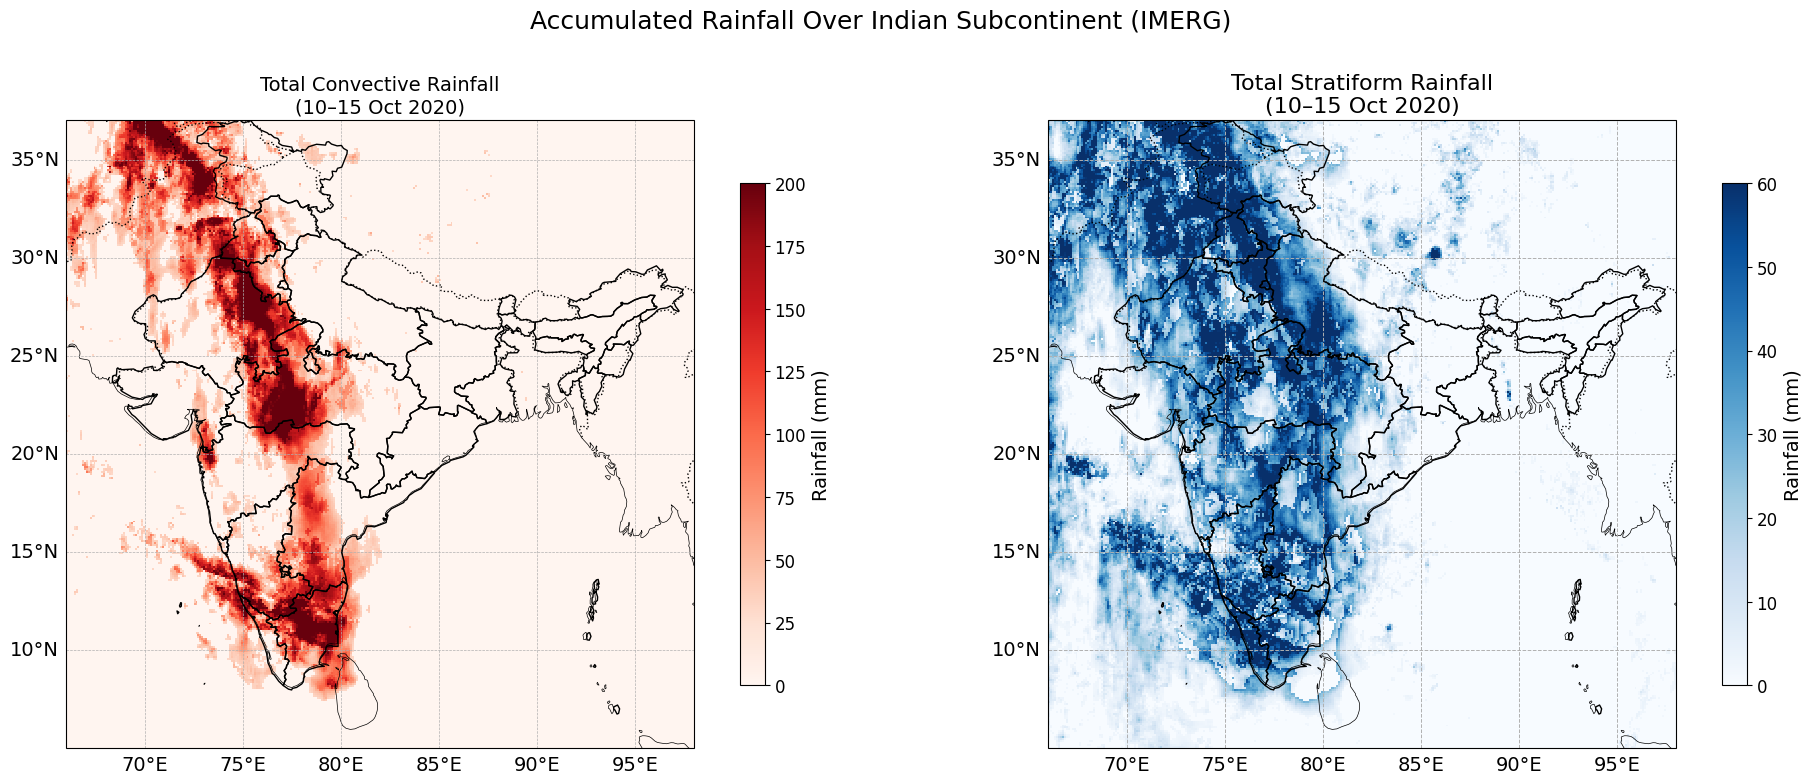

In [3]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from cartopy.feature import ShapelyFeature

# Assuming 'convective_list' and 'stratiform_list' are defined and loaded
# For example:
# import xarray as xr
# conv_total = xr.DataArray(...) 
# strat_total = xr.DataArray(...)

# --- Load shapefile for India boundary ---
shapefile_path = 'India_Shapefile/India_Shape/india_st.shp'  # Update this if needed
shape_reader = shpreader.Reader(shapefile_path)
india_feature = ShapelyFeature(shape_reader.geometries(), ccrs.PlateCarree(),
                               facecolor='none', edgecolor='black', linewidth=1)

# --- Set up the plots ---
fig, axes = plt.subplots(1, 2, figsize=(20, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# ---- Convective Rainfall Plot ----
ax1 = axes[0]
ax1.set_extent([66, 98, 5, 37], crs=ccrs.PlateCarree())
ax1.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
ax1.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=0)
ax1.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax1.add_feature(cfeature.BORDERS, linestyle=':')
ax1.add_feature(india_feature, zorder=3)

conv_plot = ax1.pcolormesh(conv_total['lon'], conv_total['lat'], conv_total,
                           cmap='Reds', vmin=0, vmax=200, shading='auto', transform=ccrs.PlateCarree())
ax1.set_title('Total Convective Rainfall\n(10–15 Oct 2020)', fontsize=14)

# --- MODIFIED COLORBAR ---
# Changed orientation to vertical and adjusted size with shrink
cbar1 = plt.colorbar(conv_plot, ax=ax1, orientation='vertical', shrink=0.8)
cbar1.set_label('Rainfall (mm)')


# ---- Add coordinates with larger font ----
gl1 = ax1.gridlines(draw_labels=True, linestyle='--', linewidth=0.5)
gl1.top_labels = False
gl1.right_labels = False
gl1.xlabel_style = {'size': 14}
gl1.ylabel_style = {'size': 14}


# ---- Stratiform Rainfall Plot ----
ax2 = axes[1]
ax2.set_extent([66, 98, 5, 37], crs=ccrs.PlateCarree())
ax2.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
ax2.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=0)
ax2.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax2.add_feature(cfeature.BORDERS, linestyle=':')
ax2.add_feature(india_feature, zorder=3)

strat_plot = ax2.pcolormesh(strat_total['lon'], strat_total['lat'], strat_total,
                            cmap='Blues', vmin=0, vmax=60, shading='auto', transform=ccrs.PlateCarree())
ax2.set_title('Total Stratiform Rainfall\n(10–15 Oct 2020)', fontsize=16)

# --- MODIFIED COLORBAR ---
# Changed orientation to vertical and adjusted size with shrink
cbar2 = plt.colorbar(strat_plot, ax=ax2, orientation='vertical', shrink=0.8)
cbar2.set_label('Rainfall (mm)')


# ---- Add coordinates with larger font ----
gl2 = ax2.gridlines(draw_labels=True, linestyle='--', linewidth=0.7)
gl2.top_labels = False
gl2.right_labels = False
gl2.xlabel_style = {'size': 14}
gl2.ylabel_style = {'size': 14}


# ---- Final Layout ----
plt.suptitle('Accumulated Rainfall Over Indian Subcontinent (IMERG)', fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

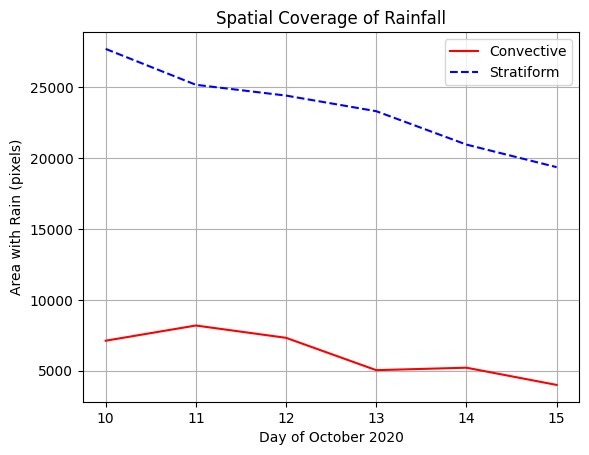

In [ ]:
conv_area = [np.count_nonzero(~np.isnan(c.values)) for c in convective_list]
strat_area = [np.count_nonzero(~np.isnan(s.values)) for s in stratiform_list]
plt.plot(days, conv_area, 'r-', label='Convective')
plt.plot(days, strat_area, 'b--', label='Stratiform')
plt.ylabel('Area with Rain (pixels)')
plt.xlabel('Day of October 2020')
plt.title('Spatial Coverage of Rainfall')
plt.legend()
plt.grid(True)
plt.show()


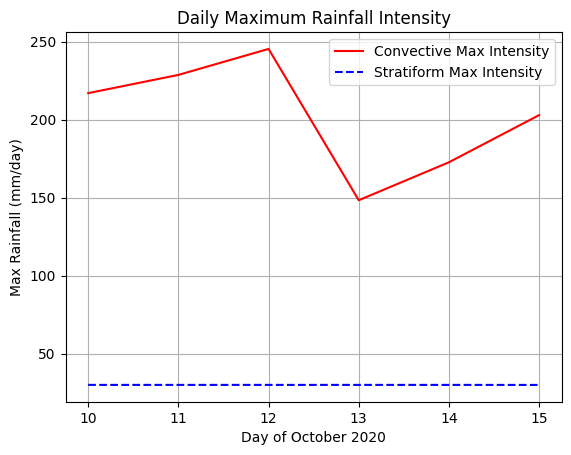

In [ ]:
conv_max = [np.nanmax(c.values) for c in convective_list]
strat_max = [np.nanmax(s.values) for s in stratiform_list]
plt.plot(days, conv_max, 'r-', label='Convective Max Intensity')
plt.plot(days, strat_max, 'b--', label='Stratiform Max Intensity')
plt.ylabel('Max Rainfall (mm/day)')
plt.xlabel('Day of October 2020')
plt.title('Daily Maximum Rainfall Intensity')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import os
file_path = 'GPM_2ADPR_07-20250609_093854/2A.GPM.DPR.V9-20211125.20201011-S001713-E014945.037590.V07A.HDF5'
print(f"File exists: {os.path.exists(file_path)}")  # Should print "True"


File exists: False


In [ ]:
import os
print(os.listdir('GPM_2ADPR_07-20250609_093854'))


['2A.GPM.DPR.V9-20211125.20201010-S001713-E014945.037590.V07A.HDF5', '2A.GPM.DPR.V9-20211125.20201010-S014946-E032219.037591.V07A.HDF5', '2A.GPM.DPR.V9-20211125.20201010-S032220-E045452.037592.V07A.HDF5', '2A.GPM.DPR.V9-20211125.20201010-S110506-E123739.037597.V07A.HDF5', '2A.GPM.DPR.V9-20211125.20201010-S123740-E141012.037598.V07A.HDF5', '2A.GPM.DPR.V9-20211125.20201011-S005806-E023039.037606.V07A.HDF5', '2A.GPM.DPR.V9-20211125.20201011-S023040-E040312.037607.V07A.HDF5', '2A.GPM.DPR.V9-20211125.20201011-S101326-E114559.037612.V07A.HDF5', '2A.GPM.DPR.V9-20211125.20201011-S114600-E131832.037613.V07A.HDF5', '2A.GPM.DPR.V9-20211125.20201012-S000626-E013859.037621.V07A.HDF5', '2A.GPM.DPR.V9-20211125.20201012-S013900-E031132.037622.V07A.HDF5', '2A.GPM.DPR.V9-20211125.20201012-S092146-E105418.037627.V07A.HDF5', '2A.GPM.DPR.V9-20211125.20201012-S105419-E122652.037628.V07A.HDF5', '2A.GPM.DPR.V9-20211125.20201012-S122653-E135925.037629.V07A.HDF5', '2A.GPM.DPR.V9-20211125.20201012-S231446-E00471

In [ ]:
import os
print(os.listdir('.'))  # Should show your .HDF5 files


['2020.ipynb', 'Annual Radial and Azimuthal Distribution of Rainfall (2014–2020).png', 'Best_Tracks.csv', 'Best_Tracks.xls', 'Best_T_2014.csv', 'Best_T_2015.csv', 'Best_T_2016.csv', 'Best_T_2017.csv', 'Best_T_2018.csv', 'Best_T_2019.csv', 'Best_T_2020.csv', 'c08063_Best Tracks__Data (1982-2024).xlsx', 'convective_20201010.png', 'convective_20201011.png', 'convective_20201012.png', 'convective_20201013.png', 'convective_20201014.png', 'convective_20201015.png', 'DD - 6. 08.19.ipynb', 'depression_center_rainfall_2014.csv', 'depression_rainfall_2014.csv', 'depression_rainfall_2016.csv', 'depression_rainfall_2017.csv', 'depression_rainfall_2018.csv', 'depression_rainfall_2019.csv', 'GPM_2ADPR_07-20250609_093854', 'GPM_3IMERGDF_07-20250607_144323', 'M2T1NXFLX_5.12.4-20250612_044055', 'meera.ipynb', 'merge.ipynb', 'merge_2014.nc', 'merge_2015.nc', 'merge_2016.nc', 'merge_2017.nc', 'merge_2018.nc', 'merge_2019.nc', 'ML.ipynb', 'RF25_ind2020_rfp25.nc', 'run.ipynb', 'Summary of Most Frequent Ma

In [ ]:
import h5py

file_path = 'GPM_2ADPR_07-20250609_093854/2A.GPM.DPR.V9-20211125.20201011-S005806-E023039.037606.V07A.HDF5'

with h5py.File(file_path, 'r') as f:
    def print_structure(name):
        print(name)
    f.visit(print_structure)


AlgorithmRuntimeInfo
FS
FS/CSF
FS/CSF/binBBBottom
FS/CSF/binBBPeak
FS/CSF/binBBTop
FS/CSF/binDFRmMLBottom
FS/CSF/binDFRmMLTop
FS/CSF/binHeavyIcePrecipBottom
FS/CSF/binHeavyIcePrecipTop
FS/CSF/flagAnvil
FS/CSF/flagBB
FS/CSF/flagHail
FS/CSF/flagHeavyIcePrecip
FS/CSF/flagMLquality
FS/CSF/flagShallowRain
FS/CSF/heightBB
FS/CSF/nHeavyIcePrecip
FS/CSF/qualityBB
FS/CSF/qualityTypePrecip
FS/CSF/typePrecip
FS/CSF/widthBB
FS/DSD
FS/DSD/binNode
FS/DSD/paramRDm
FS/DSD/phase
FS/Experimental
FS/Experimental/binMixedPhaseTop
FS/Experimental/flagGraupelHail
FS/Experimental/flagSurfaceSnowfall
FS/Experimental/precipRateESurface2
FS/Experimental/precipRateESurface2Status
FS/Experimental/seaIceConcentration
FS/Experimental/sigmaZeroProfile
FS/Experimental/surfaceSnowfallIndex
FS/FLG
FS/FLG/flagEcho
FS/FLG/flagScanPattern
FS/FLG/flagSensor
FS/FLG/qualityData
FS/FLG/qualityFlag
FS/Latitude
FS/Longitude
FS/PRE
FS/PRE/adjustFactor
FS/PRE/binClutterFreeBottom
FS/PRE/binMirrorImageL2
FS/PRE/binRealSurface
FS/P

In [ ]:
with h5py.File(file_path, 'r') as f:
    z_factor = f['FS/SLV/zFactorFinal'][:]  # Surface reflectivity (dBZ)
    lat = f['FS/Latitude'][:]
    lon = f['FS/Longitude'][:]


In [30]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

file_path = 'E:\GPM_2ADPR_07-20250609_093854\2A.GPM.DPR.V07A.20201011-S060412-E073645.040367.V07A.HDF5'

with h5py.File(file_path, 'r') as f:
    z_factor_surface = f['FS/SLV/zFactorFinalESurface'][:]  # 2D surface reflectivity (dBZ)
    lat = f['FS/Latitude'][:]  # Shape: (scans, rays)
    lon = f['FS/Longitude'][:]  # Shape: (scans, rays)


<>:5: SyntaxWarning: invalid escape sequence '\G'
<>:5: SyntaxWarning: invalid escape sequence '\G'
C:\Users\HONOR\AppData\Local\Temp\ipykernel_4176\3080223288.py:5: SyntaxWarning: invalid escape sequence '\G'
  file_path = 'E:\GPM_2ADPR_07-20250609_093854\2A.GPM.DPR.V07A.20201011-S060412-E073645.040367.V07A.HDF5'
C:\Users\HONOR\AppData\Local\Temp\ipykernel_4176\3080223288.py:5: SyntaxWarning: invalid escape sequence '\G'
  file_path = 'E:\GPM_2ADPR_07-20250609_093854\2A.GPM.DPR.V07A.20201011-S060412-E073645.040367.V07A.HDF5'


OSError: [Errno 22] Unable to synchronously open file (unable to open file: name = 'E:\GPM_2ADPR_07-20250609_093854A.GPM.DPR.V07A.20201011-S060412-E073645.040367.V07A.HDF5', errno = 22, error message = 'Invalid argument', flags = 0, o_flags = 0)

In [29]:
import xarray as xr
import numpy as np

# Replace with the actual file name inside your folder
file_path = r"E:\GPM_2ADPR_07-20250609_093854\2A.GPM.DPR.V07A.20201011-S060412-E073645.040367.V07A.HDF5"

# Open dataset
ds = xr.open_dataset(file_path, group='/NS')  # /NS is the normal scan for DPR

# Extract lat, lon, and surface reflectivity (zFactorMeasured at lowest level)
lat = ds['Latitude'].values
lon = ds['Longitude'].values
z_factor_surface = ds['zFactorMeasured'].isel(lev=0).values  # Surface reflectivity (level 0)

# Mask invalid values (e.g., fill value or NaNs)
z_factor_surface = np.where(z_factor_surface < 0, np.nan, z_factor_surface)

# Optional: Subset region over Indian subcontinent (if needed)
lat_mask = (lat >= 5) & (lat <= 37)
lon_mask = (lon >= 66) & (lon <= 98)
combined_mask = lat_mask & lon_mask

z_factor_surface_region = np.where(combined_mask, z_factor_surface, np.nan)



ValueError: did not find a match in any of xarray's currently installed IO backends ['netcdf4', 'h5netcdf', 'scipy', 'cfgrib']. Consider explicitly selecting one of the installed engines via the ``engine`` parameter, or installing additional IO dependencies, see:
https://docs.xarray.dev/en/stable/getting-started-guide/installing.html
https://docs.xarray.dev/en/stable/user-guide/io.html

In [ ]:
print("lon shape:", lon.shape)              # Should be (scans, rays)
print("lat shape:", lat.shape)              # Should be (scans, rays)
print("z_factor_surface shape:", z_factor_surface.shape)  # Should be (scans, rays)


lon shape: (7933, 49)
lat shape: (7933, 49)
z_factor_surface shape: (7933, 49)


In [27]:
import h5py
import numpy as np

file_path = 'GPM_2ADPR_07-20250609_093854/2A.GPM.DPR.V9-20211125.20201011-S005806-E023039.037606.V07A.HDF5'

with h5py.File(file_path, 'r') as f:
    lon = f['FS/Longitude'][:]
    lat = f['FS/Latitude'][:]
    z_factor_surface = f['FS/SLV/zFactorFinalESurface'][:, :, 0]  # Surface reflectivity (dBZ)

# Mask to Indian subcontinent (lat 5–37N, lon 66–98E)
region_mask = (lat >= 5) & (lat <= 37) & (lon >= 66) & (lon <= 98)
z_factor_surface_region = np.where(region_mask, z_factor_surface, np.nan)


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'GPM_2ADPR_07-20250609_093854/2A.GPM.DPR.V9-20211125.20201011-S005806-E023039.037606.V07A.HDF5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

NameError: name 'lon' is not defined

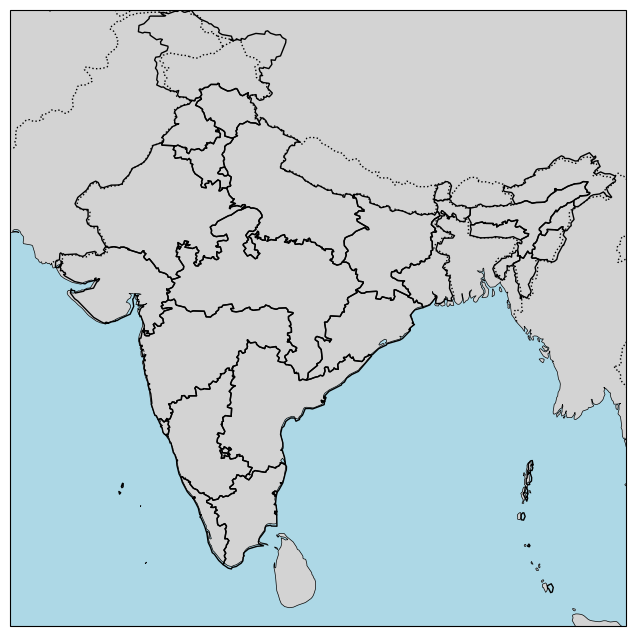

In [26]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([66, 98, 5, 37], crs=ccrs.PlateCarree())

# Add map features for Indian subcontinent
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')

# Plot masked DPR surface reflectivity
mesh = ax.pcolormesh(
    lon, lat, z_factor_surface_region,
    cmap='viridis', shading='auto', transform=ccrs.PlateCarree()
)
cbar = plt.colorbar(mesh, ax=ax, orientation='vertical', pad=0.02, aspect=30)
cbar.set_label('Surface Reflectivity (dBZ)')

plt.title('DPR Surface Reflectivity (dBZ) - 11 Oct 2020 - Indian Subcontinent')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


In [ ]:
import numpy as np

# DPR fill value for zFactor is typically -9999 (check your file's attributes to confirm)
fill_value = -9999

# Mask fill values and physically impossible reflectivity (< -10 dBZ)
z_factor_surface_masked = np.where(
    (z_factor_surface < -10) | (z_factor_surface == fill_value), 
    np.nan, 
    z_factor_surface
)


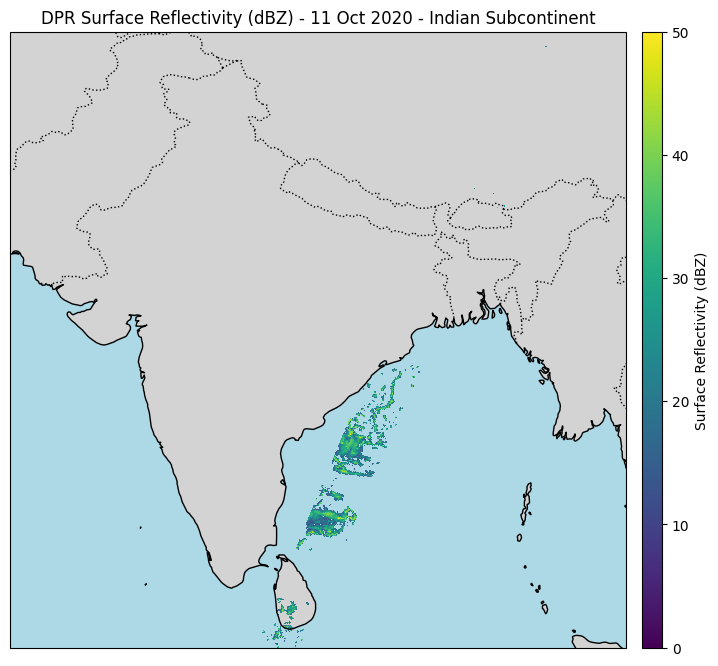

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([66, 98, 5, 37], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')

mesh = ax.pcolormesh(
    lon, lat, z_factor_surface_masked,
    cmap='viridis', shading='auto', vmin=0, vmax=50, transform=ccrs.PlateCarree()
)
cbar = plt.colorbar(mesh, ax=ax, orientation='vertical', pad=0.02, aspect=30)
cbar.set_label('Surface Reflectivity (dBZ)')
plt.title('DPR Surface Reflectivity (dBZ) - 11 Oct 2020 - Indian Subcontinent')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


In [ ]:
for file_name in file_list:
    file_path = os.path.join(folder_path, file_name)
    with h5py.File(file_path, 'r') as f:
        lat = f['FS/Latitude'][:]  # Shape: (scans, rays) e.g., (7933, 49)
        lon = f['FS/Longitude'][:]
        rain_type = f['FS/CSF/typePrecip'][:]  # Original shape: (scans+1, rays)
        rain_rate = f['FS/SLV/precipRate'][:, :, -1]  # Surface rain rate
        
        # Correctly truncate to match lat/lon dimensions
        n_scans, n_rays = lat.shape
        rain_type = rain_type[:n_scans, :n_rays]
        rain_rate = rain_rate[:n_scans, :n_rays]
        
        # Rest of the code...


KeyError: 'Unable to synchronously open object (component not found)'

In [ ]:
for file_name in file_list:
    file_path = os.path.join(folder_path, file_name)
    print(f"\nProcessing file: {file_name}")
    
    with h5py.File(file_path, 'r') as f:
        lat = f['FS/Latitude'][:]  # Shape: (n_scans, 49)
        lon = f['FS/Longitude'][:]
        rain_type = f['FS/CSF/typePrecip'][:]  # Shape: (n_scans+1, 49)
        rain_rate = f['FS/SLV/precipRate'][:, :, -1]  # Shape: (n_scans+1, 49)

        # Trim ALL variables to match lat's scan count
        n_scans = lat.shape[0]  # Use first dimension of lat (7933 or 7934)
        lat = lat[:n_scans, :]
        lon = lon[:n_scans, :]
        rain_type = rain_type[:n_scans, :]
        rain_rate = rain_rate[:n_scans, :]

        print("Shapes after trimming:")
        print("lat:", lat.shape)
        print("lon:", lon.shape)
        print("rain_type:", rain_type.shape)
        print("rain_rate:", rain_rate.shape)

        # Mask Indian subcontinent (5–37N, 66–98E)
        region_mask = (lat >= 5) & (lat <= 37) & (lon >= 66) & (lon <= 98)
        rain_rate = np.where(region_mask, rain_rate, 0)

        # Initialize accumulators on first iteration
        if convective_accum is None:
            convective_accum = np.zeros_like(rain_rate)
            stratiform_accum = np.zeros_like(rain_rate)
            lat_ref = lat
            lon_ref = lon
            print("Accumulator shapes:", convective_accum.shape)
        else:
            # Ensure subsequent files match accumulator dimensions
            if rain_rate.shape != convective_accum.shape:
                print(f"Skipping {file_name} due to shape mismatch.")
                continue

        # Accumulate rainfall
        print("Accumulating...")
        convective_accum += np.where(rain_type == 2, rain_rate, 0)
        stratiform_accum += np.where(rain_type == 1, rain_rate, 0)



Processing file: 2A.GPM.DPR.V9-20211125.20201010-S001713-E014945.037590.V07A.HDF5
Shapes after trimming:
lat: (7933, 49)
lon: (7933, 49)
rain_type: (7933, 49)
rain_rate: (7933, 49)
Accumulating...

Processing file: 2A.GPM.DPR.V9-20211125.20201010-S014946-E032219.037591.V07A.HDF5
Shapes after trimming:
lat: (7934, 49)
lon: (7934, 49)
rain_type: (7934, 49)
rain_rate: (7934, 49)
Skipping 2A.GPM.DPR.V9-20211125.20201010-S014946-E032219.037591.V07A.HDF5 due to shape mismatch.

Processing file: 2A.GPM.DPR.V9-20211125.20201010-S032220-E045452.037592.V07A.HDF5
Shapes after trimming:
lat: (7933, 49)
lon: (7933, 49)
rain_type: (7933, 49)
rain_rate: (7933, 49)
Accumulating...

Processing file: 2A.GPM.DPR.V9-20211125.20201010-S110506-E123739.037597.V07A.HDF5
Shapes after trimming:
lat: (7933, 49)
lon: (7933, 49)
rain_type: (7933, 49)
rain_rate: (7933, 49)
Accumulating...

Processing file: 2A.GPM.DPR.V9-20211125.20201010-S123740-E141012.037598.V07A.HDF5
Shapes after trimming:
lat: (7934, 49)
lon: 

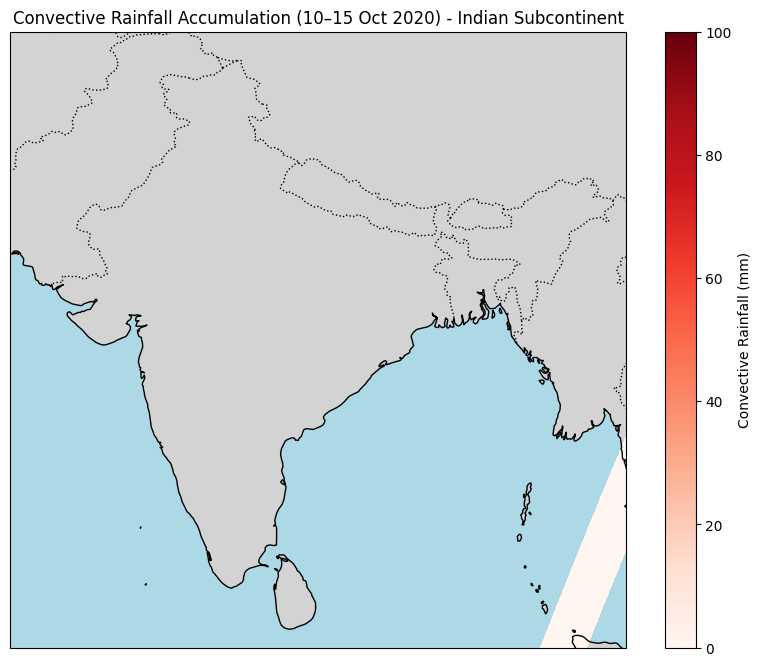

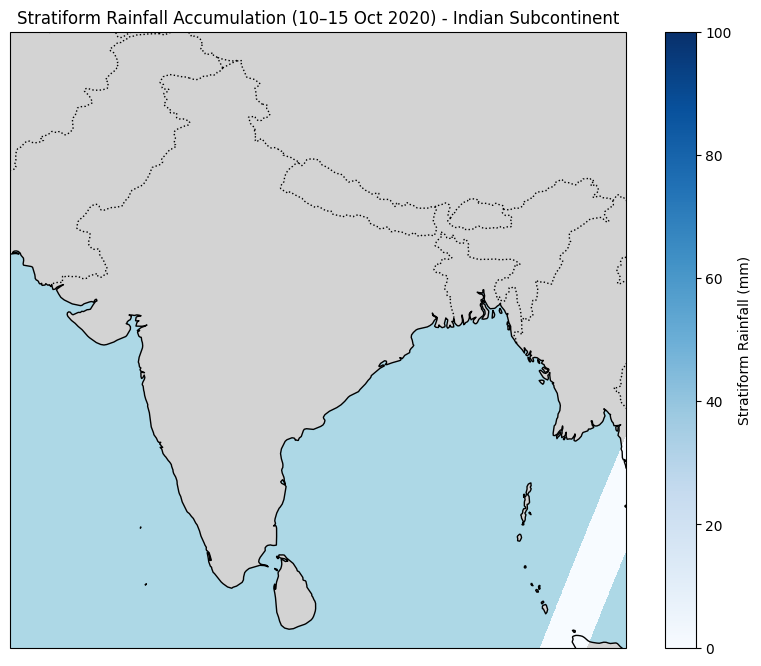

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Plot convective rainfall
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([66, 98, 5, 37], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
mesh = ax.pcolormesh(lon_ref, lat_ref, convective_accum, cmap='Reds', shading='auto', vmin=0, vmax=100)
plt.colorbar(mesh, label='Convective Rainfall (mm)')
plt.title('Convective Rainfall Accumulation (10–15 Oct 2020) - Indian Subcontinent')
plt.show()

# Plot stratiform rainfall
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([66, 98, 5, 37], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
mesh = ax.pcolormesh(lon_ref, lat_ref, stratiform_accum, cmap='Blues', shading='auto', vmin=0, vmax=100)
plt.colorbar(mesh, label='Stratiform Rainfall (mm)')
plt.title('Stratiform Rainfall Accumulation (10–15 Oct 2020) - Indian Subcontinent')
plt.show()
